# Voigt profile

In this notebook, I include a class with the Voigt profile and explain how to use it

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

import scipy.constants as const
from scipy.special import wofz

In [2]:
class LyaVoigt:
    """ Class for the Lya Voigt profile
    
    Attributes
    ----------
    lambda0_A : float
        rest Lya wavelength in Angstroms
    lambda0_m : float
        rest Lya wavelength in meters
    lambda0_km : float
        rest Lya wavelength in km
    f12 : float
        Lya oscillator strength
    Alya : float
        Lya Einstein coefficient

    Methods
    -------
    b_doppler_kms(T_K, xi_turb=0)
        Doppler parameter
    voigt_vel(v_kms, T_K)
        Voigt function H(a,x)
    cross_section(v_kms, T_K)
        absorption cross section (cm^2)
    tau(v_kms, T_K, Ncol_cm2)
        optical depth
    flux(v_kms, T_K, Ncol_cm2)
        transmitted flux
    """

    def __init__(self):
        self.lambda0_A = 1215.67
        self.lambda0_m = self.lambda0_A * 1e-10
        self.lambda0_km = self.lambda0_A / 1e13

        self.f12 = 0.4162
        self.Alya = 6.265e8  # s^-1

    def b_doppler_kms(self, T_K, xi_turb=0):
        """ Doppler parameter in km/s

        Parameters
        ----------
        T_K : float
            Temperature in K
        xi_turb : float, optional
            turbulence velocity in km/s, by default 0

        Returns
        -------
        float
            Doppler parameter in km/s
        """
        b_ms = np.sqrt(
            2 * const.Boltzmann * T_K / const.m_p + xi_turb**2
        )
        return b_ms / 1e3

    def voigt_vel(self, v_kms, T_K):
        """ Voigt function H(a,x)

        Parameters
        ----------
        v_kms : float
            velocity in km/s
        T_K : float
            temperature in K

        Returns
        -------
        float
            Voigt function H(a,x)
        """

        b = self.b_doppler_kms(T_K)

        delta_nu_D = b / self.lambda0_km

        x = v_kms / b
        a = self.Alya / (4 * np.pi * delta_nu_D)

        return np.real(wofz(x + 1j * a))

    def cross_section(self, v_kms, T_K):
        """ absorption cross section (cm^2)

        Parameters
        ----------
        v_kms : float
            velocity in km/s
        T_K : float
            temperature in K

        Returns
        -------
        float
            absorption cross section (cm^2)
        """

        b_kms = self.b_doppler_kms(T_K)
        b_ms = b_kms * 1e3

        sigma_prefactor = (
            np.sqrt(np.pi)
            * const.e**2
            / (4 * np.pi * const.epsilon_0 * const.m_e * const.c)
        )

        H = self.voigt_vel(v_kms, T_K)

        sigma_m2 = (
            sigma_prefactor
            * self.f12
            * self.lambda0_m
            / b_ms
            * H
        )

        return sigma_m2 * 1e4  # convert to cm^2

    # optical depth
    def tau(self, v_kms, T_K, Ncol_cm2):
        """ optical depth

        Parameters
        ----------
        v_kms : float
            velocity in km/s
        T_K : float
            temperature in K
        Ncol_cm2 : float
            column density in cm^-2

        Returns
        -------
        float
            optical depth
        """
        return Ncol_cm2 * self.cross_section(v_kms, T_K)

    # transmitted flux
    def flux(self, v_kms, T_K, Ncol_cm2):
        """ transmitted flux

        Parameters
        ----------
        v_kms : float
            velocity in km/s
        T_K : float
            temperature in K
        Ncol_cm2 : float
            column density in cm^-2

        Returns
        -------
        float
            transmitted flux
        """
        return np.exp(-self.tau(v_kms, T_K, Ncol_cm2))

Initialize class

In [3]:
lya_abs = LyaVoigt()

### Dependence of the absorption on the column density

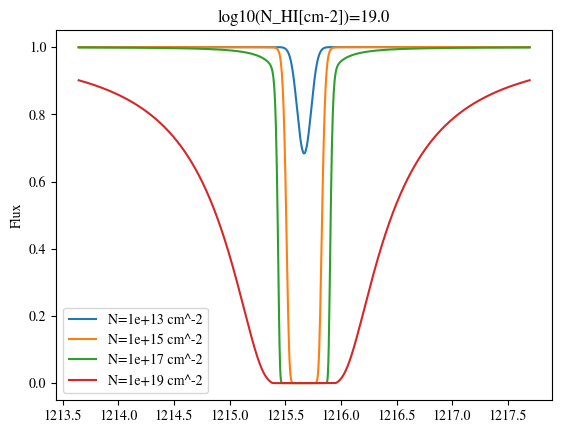

In [9]:
vdiff = 500
v_kms = np.linspace(-vdiff, vdiff, 1000)
T = 2.4e4

for N_HI_cm2 in [1e13, 1e15, 1e17, 1e19]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    delta_lambda = v_kms/3e5*1215.67 + 1215.67
    plt.plot(delta_lambda, profile, label=f"N={N_HI_cm2:.0e} cm^-2")

# plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()

### Dependence of the absorption on the temperature for different column densities

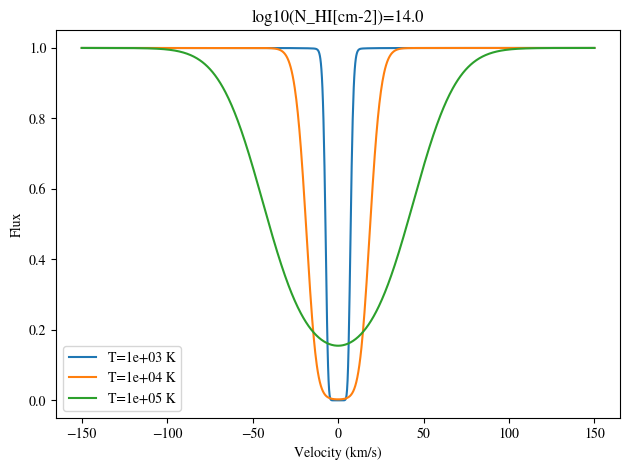

In [13]:
vdiff = 150
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e14

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")

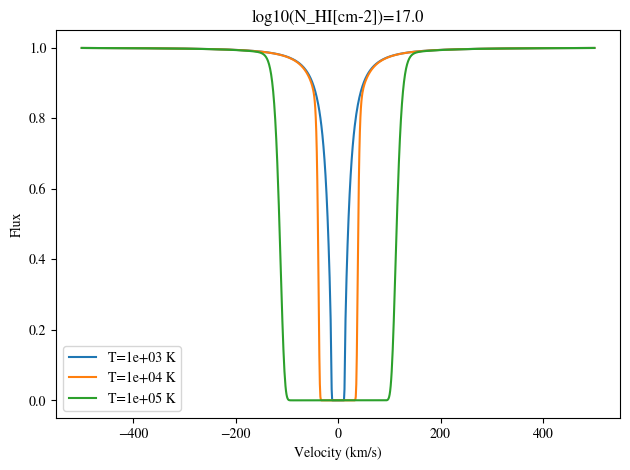

In [14]:
vdiff = 500
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e17

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")

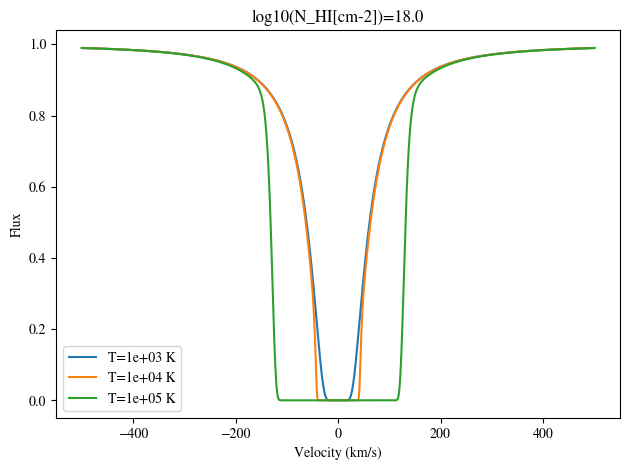

In [15]:
vdiff = 500
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e18

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])=" + str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_" + str(np.log10(N_HI_cm2)) + ".png")

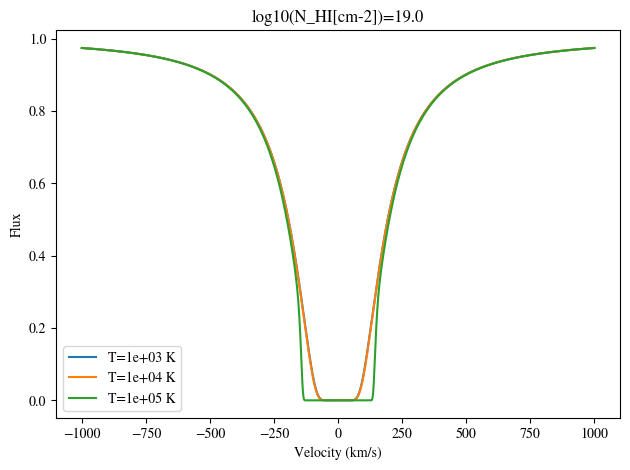

In [16]:
vdiff = 1000
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e19

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")